# 02c - Benchmarks and diagnostics

**Requires:** run `02a_pipeline.ipynb` first.

- §11 Synthetic corruption benchmark
- §11b Cross-lab generalisation
- §12 Parallel multi-video processing
- §13 Diagnostics: cost balance, displacement, convergence, residuals
- §14 Realistic corruption benchmark

In [1]:
# ── Load experiment configuration from YAML ──────────────────────────────────
import sys, os, random
from pathlib import Path

_cwd = Path(os.getcwd())
REPO_ROOT = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent]
     if (p / "src").exists() and (p / "configs").exists()),
    _cwd
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from omegaconf import OmegaConf
import numpy as np

cfg = OmegaConf.load(REPO_ROOT / "configs/skeleton.yaml")

# Dataset
LAB_ID            = cfg.dataset.lab_id
FRAME_LIMIT       = cfg.dataset.frame_limit
FRAME_LIMIT_BENCH = cfg.dataset.frame_limit_bench
RANDOM_SEED       = cfg.dataset.random_seed

# Outlier detection
SPEED_MAD_K          = cfg.outlier.speed_mad_k
LENGTH_THRESHOLD     = cfg.outlier.length_threshold
VIOLATION_REPORT_THR = cfg.outlier.violation_report_thr
DETECTION_N_SIGMA    = cfg.outlier.detection_n_sigma

# Optimizer weights
LAMBDA_L          = cfg.weights.L
LAMBDA_S          = cfg.weights.S
LAMBDA_T          = cfg.weights.T
LAMBDA_ACC        = cfg.weights.acc
LAMBDA_ANGLE      = cfg.weights.angle
LAMBDA_JERK       = cfg.weights.jerk
LAMBDA_ANGLE_CONT = cfg.weights.angle_cont

# Solver
OUTLIER_ADHESION           = cfg.solver.outlier_adhesion
N_PASSES                   = cfg.solver.n_passes
CONFIDENCE_SIGMA           = cfg.solver.confidence_sigma
ADAPTIVE_K                 = cfg.solver.adaptive_k
MAX_DISP_FACTOR            = cfg.solver.max_disp_factor
NON_OUTLIER_ADHESION_SCALE = cfg.solver.non_outlier_adhesion_scale

# Benchmark synthetic
BENCH_NOISE_STD       = cfg.benchmark.noise_std
BENCH_DROPOUT_RATE    = cfg.benchmark.dropout_rate
BENCH_SWAP_PROB       = cfg.benchmark.swap_prob
BENCH_SPEED_SPIKES    = cfg.benchmark.speed_spikes
BENCH_DRIFT_AMPLITUDE = cfg.benchmark.drift_amplitude
BENCH_LAMBDA_L        = cfg.benchmark.lambda_l
BENCH_ADHESION        = cfg.benchmark.adhesion

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"▶  config loaded from configs/skeleton.yaml")
print(f"   LAB_ID={LAB_ID}  FRAME_LIMIT={FRAME_LIMIT}  RANDOM_SEED={RANDOM_SEED}")
print(f"   LAMBDA_L={LAMBDA_L}  LAMBDA_T={LAMBDA_T}  OUTLIER_ADHESION={OUTLIER_ADHESION}")


▶  config loaded from configs/skeleton.yaml
   LAB_ID=CalMS21_task1  FRAME_LIMIT=1500  RANDOM_SEED=42
   LAMBDA_L=12.0  LAMBDA_T=0.8  OUTLIER_ADHESION=0.6


In [2]:
# ── Load artifacts produced by 02a_pipeline.ipynb ────────────────────────────
import pickle, json, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# Probe both the canonical repo results dir and the notebook-local one
# (the latter is used when 02a was run before the REPO_ROOT fix).
_results_candidates = [REPO_ROOT / "results", Path(os.getcwd()) / "results"]
RESULTS_DIR = next(
    (p for p in _results_candidates if (p / "run_config.json").exists()),
    REPO_ROOT / "results",
)
OUTPUTS_DIR = REPO_ROOT / "outputs"

_run_cfg = json.load(open(RESULTS_DIR / "run_config.json"))
VIDEO_ID   = _run_cfg["video_id"]
MOUSE_ID   = _run_cfg["mouse_id"]
ARENA_DIAG = _run_cfg["arena_diag"]
VIDEO_FPS  = _run_cfg.get("video_fps", 30)

df_sample    = pickle.load(open(RESULTS_DIR / f"df_sample_{VIDEO_ID}.pkl",    "rb"))
df_corrected = pickle.load(open(RESULTS_DIR / f"df_corrected_{VIDEO_ID}.pkl", "rb"))
skeleton     = pickle.load(open(RESULTS_DIR / f"skeleton_{LAB_ID}.pkl",       "rb"))

# L_ref_px convenience alias used in §9b
from src.skeleton.mouse_skeleton import _to_wide, _segment_length
_w_ref  = _to_wide(df_sample[df_sample["mouse_id"] == MOUSE_ID])
_l_ref  = _segment_length(_w_ref, "nose", "tail_base")
L_ref_px = float(_l_ref[_l_ref > 10].median())

print(f"Loaded: VIDEO_ID={VIDEO_ID} | MOUSE_ID={MOUSE_ID}")
print(f"  df_sample: {len(df_sample)} rows  |  df_corrected: {len(df_corrected)} rows")
print(f"  skeleton: {len(skeleton.keypoints)} kp, {len(skeleton.edges)} edges, "
      f"L_body={skeleton.L_body_median_px:.1f} px")
print(f"  L_ref_px={L_ref_px:.1f} px")


Loaded: VIDEO_ID=13638642 | MOUSE_ID=1
  df_sample: 21000 rows  |  df_corrected: 21000 rows
  skeleton: 7 kp, 7 edges, L_body=175.5 px
  L_ref_px=207.5 px


## §11 Synthetic corruption benchmark

§7 of `02a_pipeline` exported the summary for the reference video: about 56%
fewer violations, with the effect size and the JSON and Parquet artefacts written
to `outputs/`.

Everything so far ran on real tracking, where the errors are whatever the detector
happened to make. This section injects known corruption instead, so recovery can be
measured per error type rather than in aggregate.

| Parameter | Value |
|-----------|-------|
| `BENCH_NOISE_STD` | 5 px |
| `BENCH_DROPOUT_RATE` | 5% of rows |
| `BENCH_SWAP_PROB` | 2% of frames |
| `BENCH_LAMBDA_L` | 100 (aggressive recovery) |
| `BENCH_ADHESION` | 0.4 (standard) |
| `LAMBDA_ACC` | 0.2 |
| `LAMBDA_ANGLE` | 10.0 |

df_bench: 400 frames (FRAME_LIMIT_BENCH=400)
Ejecutando benchmark por tipo de corrupción...


  mouse 1:   0%|          | 0/14 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/9 [00:00<?, ?win/s]

  mouse 1: 0win [00:00, ?win/s]

  mouse 2: 0win [00:00, ?win/s]

...

  mouse 2:   0%|          | 0/6 [00:00<?, ?win/s]

corruption_type  rate_clean  viol_rate_corrupted  viol_rate_recovered  violation_reduction_pct  male_corrupted  male_recovered  male_reduction_pct  rmse_nose_norm  rmse_tail_norm  temporal_inconsistency_corrupted  temporal_inconsistency_recovered  swap_recovery_rate  jerk_mean_norm
 gaussian_noise      0.0000               0.5518               0.6061                  -9.8000          4.0393          4.4257             -9.6000          0.0036          0.0034                            0.0248                            0.0042                 NaN          0.0042
       dropouts      0.0000               0.0000               0.0000                 100.0000             NaN             NaN                 NaN          0.0000          0.0000                            0.0000                            0.0000                 NaN          0.0000
          swaps      0.0000               0.0000               0.0000                 100.0000             NaN             NaN                 NaN     

  mouse 1:   0%|          | 0/9 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/11 [00:00<?, ?win/s]

  corrompida  : mean_cross=0.5588  p95=0.9890  pct_bent=57.0%
  recuperada  : mean_cross=0.5675  p95=0.9938  pct_bent=58.5%


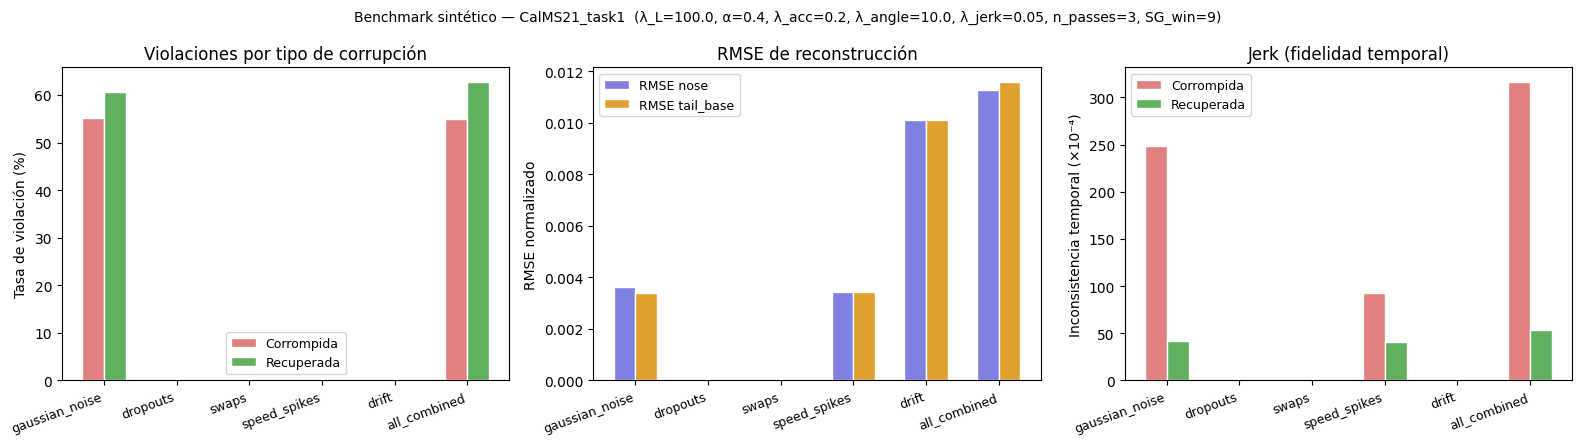


Tipo de corrupción con mayor tasa residual: all_combined (62.6%)
Tipo de corrupción con mayor reducción:     dropouts (100.0%)


In [3]:
import time

from src.skeleton.keypoint_smoother import smooth_video
from src.skeleton.metrics import angular_alignment_score, benchmark_by_corruption_type, inject_corruption
from src.skeleton.mouse_skeleton import _to_wide, _segment_length

rng_bench = np.random.default_rng(RANDOM_SEED)
_perf = {}

# ── Recovery function, with the benchmark parameters ─────────────────────
# smooth_fn must return (df_recovered, report), exactly like smooth_video.
# pre_smooth_window=9 is a wider Savitzky-Golay kernel, which absorbs the
# high-frequency Gaussian noise before the optimiser tries to satisfy the
# constraints against it.
def _bench_smooth(df_corrupt):
    return smooth_video(
        tracking_df=df_corrupt,
        lab_id=LAB_ID,
        skeleton=skeleton,
        speed_sigma=SPEED_MAD_K,
        length_threshold=LENGTH_THRESHOLD,
        lambda_l=BENCH_LAMBDA_L,
        lambda_t=LAMBDA_T,
        lambda_acc=LAMBDA_ACC,
        lambda_angle=LAMBDA_ANGLE,
        lambda_jerk=LAMBDA_JERK,
        lambda_angle_cont=LAMBDA_ANGLE_CONT,
        auto_edge_lambdas=True,
        pre_smooth=True,
        pre_smooth_window=9,
        outlier_adhesion=BENCH_ADHESION,
        detection_n_sigma=DETECTION_N_SIGMA,
        n_passes=N_PASSES,
    )

# ── Frame subset for the benchmark, which avoids an L-BFGS-B timeout ────────
_bench_frame_ids = sorted(df_sample['video_frame'].unique())[:FRAME_LIMIT_BENCH]
df_bench = df_sample[df_sample['video_frame'].isin(_bench_frame_ids)].copy()
print(f'df_bench: {df_bench["video_frame"].nunique()} frames (FRAME_LIMIT_BENCH={FRAME_LIMIT_BENCH})')

# ── 1. Benchmark per corruption type ─────────────────────────────────────
print('Running the benchmark per corruption type...')
_t0_bench = time.perf_counter()

bench_results = benchmark_by_corruption_type(
    df_clean=df_bench,
    skeleton=skeleton,
    mouse_id=MOUSE_ID,
    smooth_fn=_bench_smooth,
    arena_diag=ARENA_DIAG,
    noise_std=BENCH_NOISE_STD,
    dropout_rate=BENCH_DROPOUT_RATE,
    swap_prob=BENCH_SWAP_PROB,
    threshold=LENGTH_THRESHOLD,
    rng_seed=RANDOM_SEED,
)
_bench_time_s = round(time.perf_counter() - _t0_bench, 3)
_perf['benchmark_s'] = _bench_time_s

bench_df = bench_results.copy()
print(bench_df.to_string(index=False, float_format='{:.4f}'.format))
print(f'\nTiempo total benchmark: {_bench_time_s} s')

# ── 2. Continuous deviation metrics, over the combined signal ────────────
print('\n── Metrics per corruption type ─────────────────────────────────────')
_row_all = bench_df[bench_df['corruption_type'] == 'all_combined']
if len(_row_all):
    r = _row_all.iloc[0]
    print(f'  violation_rate (corrompida): {r["viol_rate_corrupted"]:.1%}')
    print(f'  violation_rate (recuperada): {r["viol_rate_recovered"]:.1%}')
    print(f'  reduction: {r["violation_reduction_pct"]:.1f}%')
    print(f'  RMSE nose (norm.):      {r["rmse_nose_norm"]:.5f}')
    print(f'  RMSE tail_base (norm.): {r["rmse_tail_norm"]:.5f}')
    if 'temporal_inconsistency_recovered' in r.index:
        print(f'  Temporal inconsistency (corrupted): {r["temporal_inconsistency_corrupted"]:.6f}')
        print(f'  Temporal inconsistency (recovered): {r["temporal_inconsistency_recovered"]:.6f}')

# ── 3. Swap recovery rate ─────────────────────────────────────────────────
print('\n── Swap recovery rate ────────────────────────────────────────────')
_swap_row = bench_df[bench_df['corruption_type'] == 'swaps']
if len(_swap_row) and 'swap_recovery_rate' in _swap_row.columns:
    sr = _swap_row.iloc[0]
    print(f'  swaps — violation_rate: {sr["viol_rate_corrupted"]:.1%} → {sr["viol_rate_recovered"]:.1%}  '
          f'(reduction: {sr["violation_reduction_pct"]:.1f}%)')
    if not (isinstance(sr['swap_recovery_rate'], float) and np.isnan(sr['swap_recovery_rate'])):
        print(f'  swap_recovery_rate: {sr["swap_recovery_rate"]:.1%}')
    else:
        print('  swap_recovery_rate: n/a (too few swaps in the sample)')
# ── 4. Angular alignment score over the recovered all_combined signal ────
print('\n── Alineamiento angular (all_combined: corrompida vs. recuperada) ────')
_rng2 = np.random.default_rng(RANDOM_SEED)
_df_corr_all = inject_corruption(
    df_bench,
    noise_std=BENCH_NOISE_STD,
    dropout_rate=BENCH_DROPOUT_RATE,
    swap_prob=BENCH_SWAP_PROB,
    rng=_rng2,
)
_df_rec_all, _ = _bench_smooth(_df_corr_all)
for _lbl, _df in [('corrompida', _df_corr_all), ('recuperada', _df_rec_all)]:
    try:
        _as = angular_alignment_score(_df, skeleton, MOUSE_ID)
        print(f'  {_lbl:12s}: mean_cross={_as["mean_abs_cross"]:.4f}  '
              f'p95={_as["p95_abs_cross"]:.4f}  '
              f'pct_bent={_as["pct_bent"]:.1%}')
    except Exception as _e:
        print(f'  {_lbl:12s}: {_e}')

# ── 5. Plot: violations, RMSE and temporal inconsistency ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

corruption_types = bench_df['corruption_type'].tolist()
x = np.arange(len(corruption_types))
w = 0.3

ax = axes[0]
ax.bar(x - w/2, bench_df['viol_rate_corrupted'] * 100, width=w, label='Corrompida', color='#e08080', edgecolor='white')
ax.bar(x + w/2, bench_df['viol_rate_recovered'] * 100, width=w, label='Recuperada', color='#60b060', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(corruption_types, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Violation rate (%)'); ax.set_title('Violations per corruption type')
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(x - w/2, bench_df['rmse_nose_norm'],  width=w, label='RMSE nose',      color='#8080e0', edgecolor='white')
ax.bar(x + w/2, bench_df['rmse_tail_norm'],  width=w, label='RMSE tail_base', color='#e0a030', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(corruption_types, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Normalised RMSE'); ax.set_title('Reconstruction RMSE')
ax.legend(fontsize=9)

ax = axes[2]
if 'temporal_inconsistency_corrupted' in bench_df.columns:
    ti_c = bench_df['temporal_inconsistency_corrupted'].fillna(0)
    ti_r = bench_df['temporal_inconsistency_recovered'].fillna(0)
    ax.bar(x - w/2, ti_c * 1e4, width=w, label='Corrompida', color='#e08080', edgecolor='white')
    ax.bar(x + w/2, ti_r * 1e4, width=w, label='Recuperada', color='#60b060', edgecolor='white')
    ax.set_ylabel('Inconsistencia temporal (×10⁻⁴)')
    ax.set_title('Jerk (fidelidad temporal)')
else:
    ax.text(0.5, 0.5, 'Not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xticks(x); ax.set_xticklabels(corruption_types, rotation=20, ha='right', fontsize=9)
ax.legend(fontsize=9)

plt.suptitle(f'Synthetic benchmark - {LAB_ID}  '
             f'(λ_L={BENCH_LAMBDA_L}, α={BENCH_ADHESION}, '
             f'λ_acc={LAMBDA_ACC}, λ_angle={LAMBDA_ANGLE}, '
             f'λ_jerk={LAMBDA_JERK}, n_passes={N_PASSES}, SG_win=9)',
             fontsize=10)
plt.tight_layout()
plt.show()

# ── 6. Diagnostic: which corruption type is hardest ──────────────────────
_valid = bench_df.dropna(subset=['viol_rate_recovered'])
if len(_valid):
    _worst = _valid.loc[_valid['viol_rate_recovered'].idxmax()]
    _best  = _valid.loc[_valid['violation_reduction_pct'].idxmax()]
    print(f'\nCorruption type with the highest residual rate: '
          f'{_worst["corruption_type"]} ({_worst["viol_rate_recovered"]:.1%})')
    print(f'Corruption type with the largest reduction:    '
          f'{_best["corruption_type"]} ({_best["violation_reduction_pct"]:.1f}%)')
    if _worst['corruption_type'] == 'swaps':
        print('  -> Identity swaps are the main challenge: they need temporal')
        print('     identity continuity, which cannot be fixed frame by frame.')
        print('     The lambda_angle_cont penalty helps but does not fully solve it.')
    elif _worst['corruption_type'] == 'dropouts':
        print('  -> (0,0) dropouts are the main challenge: spatial-threshold detection')
        print('     should improve with the per-keypoint detector.')


## §11b Generalising to other laboratories

Runs the full pipeline over three labs to see whether it transfers:

- **CalMS21_task1**: the reference, already analysed in §3 to §6
- **CalMS21_task2**: same capture setup, possibly a different distribution
- **CRIM13**: a different multi-camera station, possibly a different skeleton

Labs with no data available are skipped rather than raising.

In [4]:
# Select the candidate labs
import importlib
import src.skeleton.mouse_skeleton as _msm
importlib.reload(_msm)          # reload the fixed module
import src.skeleton as _skel_pkg
importlib.reload(_skel_pkg)     # refresh the package namespace too

from src.data.loader import load_tracking, load_metadata, TRAIN_TRACKING_DIR
from src.skeleton import build_skeleton, fit_skeleton, compute_constraint_violations, smooth_video
from src.skeleton.mouse_skeleton import _to_wide, _segment_length
from src.skeleton._parallel_worker import process_one_video_population

CROSSLAB_TARGETS = ["CalMS21_task1", "CalMS21_task2", "CRIM13"]
MAX_VID_PER_LAB  = 2   # videos per lab

_all_meta = load_metadata()  # load full train metadata (has 'lab_id' column)

_crosslab_meta = {}
for _lab in CROSSLAB_TARGETS:
    try:
        _lab_meta = _all_meta[_all_meta['lab_id'] == _lab]
        if len(_lab_meta) > 0:
            _crosslab_meta[_lab] = _lab_meta.head(MAX_VID_PER_LAB)
            print(f"  {_lab}: {len(_crosslab_meta[_lab])} videos available")
        else:
            print(f"  {_lab}: no metadata; skipped")
    except Exception as _e:
        print(f"  {_lab}: error ({_e}) — omitido")

print(f"\nTotal labs: {len(_crosslab_meta)}")


  CalMS21_task1: 2 vídeos disponibles
  CalMS21_task2: 2 vídeos disponibles
  CRIM13: 2 vídeos disponibles

Total laboratorios: 3


In [5]:
# Per-lab skeleton statistics (diagnostic)
print("\n=== Per-lab skeleton statistics ===\n")

_skeletons = {}
for _lab in CROSSLAB_TARGETS:
    if _lab in _crosslab_meta:
        _vid = _crosslab_meta[_lab].iloc[0]["video_id"]
        _df_temp = load_tracking(_vid, _lab)
        if _df_temp is None or len(_df_temp) < 50:
            print(f"{_lab}: no valid data")
            continue

        _kp_hint = _df_temp["bodypart"].unique().tolist()
        _skl_temp = build_skeleton(_lab, keypoints_hint=_kp_hint)
        fit_skeleton(_skl_temp, _df_temp)
        _skeletons[_lab] = _skl_temp

        _l_std_all = np.array([float(e.L_std) for e in _skl_temp.edges], dtype=float)
        _l_std_valid = _l_std_all[np.isfinite(_l_std_all) & (_l_std_all > 0)]

        if _l_std_valid.size > 0:
            _thr_lab = float(np.mean(3 * np.maximum(_l_std_valid, 1e-6)))
            _thr_vs_global = (_thr_lab - LENGTH_THRESHOLD) / LENGTH_THRESHOLD * 100
            _thr_label = f"{_thr_lab:.3f} ({_thr_vs_global:+.1f}% vs global)"
            _lstd_mean = float(np.mean(_l_std_valid))
            _lstd_max = float(np.max(_l_std_valid))
        else:
            _thr_lab = float(LENGTH_THRESHOLD)
            _thr_label = f"{_thr_lab:.3f} (fallback global)"
            _lstd_mean = np.nan
            _lstd_max = np.nan

        print(f"{_lab}:")
        print(f"  Keypoints:      {len(_skl_temp.keypoints)}")
        print(f"  Edges:          {len(_skl_temp.edges)}")
        print(f"  L_body (px):    {_skl_temp.L_body_median_px:.1f}")
        print(f"  Valid L_std:    {_l_std_valid.size}/{len(_l_std_all)}")
        print(f"  L_std (mean):   {_lstd_mean:.4f}" if np.isfinite(_lstd_mean) else "  L_std (mean):   n/a")
        print(f"  L_std (max):    {_lstd_max:.4f}" if np.isfinite(_lstd_max) else "  L_std (max):    n/a")
        print(f"  Adaptive threshold: {_thr_label}")

        _edges_by_std = sorted(
            _skl_temp.edges,
            key=lambda e: float(e.L_std) if np.isfinite(e.L_std) else -1.0,
            reverse=True,
        )[:3]
        print("  Most variable edges:")
        for e in _edges_by_std:
            _std_txt = f"{float(e.L_std):.4f}" if np.isfinite(e.L_std) else "n/a"
            print(f"    {e.src}→{e.dst}: L_ref={e.L_ref:.3f}, L_std={_std_txt}")
        print()

print(f"\n{'─'*70}")
print(f"Threshold global (CONFIG):     {LENGTH_THRESHOLD:.3f}")
print(f"Threshold CalMS21_task1 (ref): {float(np.mean([3 * max(e.L_std, 1e-6) for e in skeleton.edges if np.isfinite(e.L_std)])):.3f}")
print(f"{'─'*70}\n")


=== Estadísticas de esqueleto por laboratorio ===

CalMS21_task1:
  Keypoints:      7
  Edges:          7
  L_body (px):    175.5
  L_std válidos:  7/7
  L_std (mean):   0.6119
  L_std (max):    0.9789
  Adaptive threshold: 1.836 (-0.2% vs global)
  Aristas más variables:
    hip_left→tail_base: L_ref=0.350, L_std=0.9789
    nose→neck: L_ref=0.358, L_std=0.9144
    hip_right→tail_base: L_ref=0.343, L_std=0.8986

CalMS21_task2:
  Keypoints:      7
  Edges:          7
  L_body (px):    193.0
  L_std válidos:  7/7
  L_std (mean):   0.1864
  L_std (max):    0.3223
  Adaptive threshold: 0.559 (-69.6% vs global)
  Aristas más variables:
    hip_right→tail_base: L_ref=0.351, L_std=0.3223
    neck→hip_left: L_ref=0.431, L_std=0.2058
    nose→neck: L_ref=0.376, L_std=0.2051

CRIM13:
  Keypoints:      7
  Edges:          7
  L_body (px):    112.9
  L_std válidos:  7/7
  L_std (mean):   0.5842
  L_std (max):    0.8207
  Adaptive threshold: 1.753 (-4.8% vs global)
  Aristas más variables:
    nos

In [6]:
# Run the pipeline per lab
import time
import warnings as _warnings
import pandas as pd


def _estimate_lab_threshold(_df_lab_tracking, _skl_lab, _fallback):
    """Estimate lab-specific threshold from finite normalized edge stds.

    The raw estimate (mean of 3*std per edge) is clamped to
    [0.5*fallback, 2.0*fallback] to avoid two failure modes:
      - Too tight  (< 0.5×global): flags normal frames as violations →
        optimizer degrades clean videos (e.g. CalMS21_task2 @ 0.402)
      - Too loose  (> 2.0×global): misses real anomalies on noisy labs
    """
    _FLOOR = 0.5 * float(_fallback)
    _CEIL  = 2.0 * float(_fallback)

    try:
        _wide = _to_wide(_df_lab_tracking)
        _l_body = _segment_length(_wide, "nose", "tail_base")
        _l_body = _l_body.replace([np.inf, -np.inf], np.nan)
        _l_body = _l_body.where(_l_body > 1e-6)

        _stds = []
        for _e in _skl_lab.edges:
            _seg = _segment_length(_wide, _e.src, _e.dst)
            _norm = (_seg / _l_body).replace([np.inf, -np.inf], np.nan)
            _valid = _norm.dropna()
            _valid = _valid[_valid > 0]
            if len(_valid) >= 10:
                _sd = float(_valid.std())
                if np.isfinite(_sd) and _sd > 0:
                    _stds.append(_sd)

        if len(_stds) > 0:
            _thr_raw = float(np.mean(3 * np.maximum(np.array(_stds, dtype=float), 1e-6)))
            _thr = float(np.clip(_thr_raw, _FLOOR, _CEIL))
            _tag = f"data" + (" [clamped↑]" if _thr > _thr_raw else " [clamped↓]" if _thr < _thr_raw else "")
            return _thr, len(_stds), _tag

        _fit_stds = [float(e.L_std) for e in _skl_lab.edges if np.isfinite(e.L_std) and e.L_std > 0]
        if len(_fit_stds) > 0:
            _thr_raw = float(np.mean(3 * np.maximum(np.array(_fit_stds, dtype=float), 1e-6)))
            _thr = float(np.clip(_thr_raw, _FLOOR, _CEIL))
            _tag = "fit" + (" [clamped↑]" if _thr > _thr_raw else " [clamped↓]" if _thr < _thr_raw else "")
            return _thr, len(_fit_stds), _tag

        return float(_fallback), 0, "global"
    except Exception:
        return float(_fallback), 0, "global"


# ── Pre-compute reference skeletons per lab (using ALL videos) ───────────
print("\n=== Building the per-lab reference skeletons ===\n")
print(f"  Threshold global (CONFIG): {LENGTH_THRESHOLD:.3f}")
print(f"  Clamp range: [{0.5*LENGTH_THRESHOLD:.3f}, {2.0*LENGTH_THRESHOLD:.3f}]\n")
_lab_skeletons = {}
_lab_thresholds = {}

for _lab in CROSSLAB_TARGETS:
    if _lab in _crosslab_meta:
        print(f"{_lab}: ", end="", flush=True)
        _all_tracking = []
        for _, _row in _crosslab_meta[_lab].iterrows():
            _vid = _row["video_id"]
            _df_temp = load_tracking(_vid, _lab)
            if _df_temp is not None and len(_df_temp) >= 50:
                _frames = sorted(_df_temp["video_frame"].unique())
                if len(_frames) > 500:
                    _rng_sample = np.random.default_rng(RANDOM_SEED)
                    _sample_frames = _rng_sample.choice(_frames, 500, replace=False)
                    _df_temp = _df_temp[_df_temp["video_frame"].isin(_sample_frames)]
                _all_tracking.append(_df_temp)

        if len(_all_tracking) > 0:
            _df_lab = pd.concat(_all_tracking, ignore_index=True)
            _kp_hint = _df_lab["bodypart"].unique().tolist()
            _skl_lab = build_skeleton(_lab, keypoints_hint=_kp_hint)
            fit_skeleton(_skl_lab, _df_lab)

            _thr_lab, _n_valid, _src = _estimate_lab_threshold(_df_lab, _skl_lab, LENGTH_THRESHOLD)

            _lab_skeletons[_lab] = _skl_lab
            _lab_thresholds[_lab] = _thr_lab

            _thr_vs_global = (_thr_lab - LENGTH_THRESHOLD) / LENGTH_THRESHOLD * 100
            print(
                f"{len(_all_tracking)} videos, L_thr={_thr_lab:.3f} "
                f"({_thr_vs_global:+.1f}% vs global, src={_src}, valid_edges={_n_valid})"
            )
        else:
            print("⚠ No valid data")

print(f"\n{'─'*70}\n")

# ── Process videos using pre-computed lab skeletons ──────────────────────
_crosslab_rows = []

for _lab, _meta in _crosslab_meta.items():
    print(f"\n── {_lab} ({'same as the reference' if _lab == LAB_ID else ''}) ──")

    if _lab not in _lab_skeletons:
        print("  ⚠ Skeleton not available; skipped")
        continue

    _skl = _lab_skeletons[_lab]
    _length_thr_lab = _lab_thresholds[_lab]
    print(f"  [Usando L_thr={_length_thr_lab:.3f}]")

    for _, _row in _meta.iterrows():
        _vid = _row["video_id"]
        print(f"  {_vid} ...", end=" ", flush=True)
        try:
            with _warnings.catch_warnings():
                _warnings.simplefilter("ignore", RuntimeWarning)
                _df_t = load_tracking(_vid, _lab)
                if _df_t is None or len(_df_t) < 50:
                    print("EMPTY; skipped")
                    continue

                # Use CONSECUTIVE block starting at random position (not first N frames)
                _all_frames = sorted(_df_t["video_frame"].unique())
                if len(_all_frames) > FRAME_LIMIT_BENCH:
                    _rng_cross = np.random.default_rng(RANDOM_SEED + hash(_vid) % 1000)
                    _max_start = len(_all_frames) - FRAME_LIMIT_BENCH
                    _start_idx = _rng_cross.integers(0, max(_max_start, 1))
                    _sample_frames = _all_frames[_start_idx : _start_idx + FRAME_LIMIT_BENCH]
                    _df_t_sample = _df_t[_df_t["video_frame"].isin(_sample_frames)].copy()
                else:
                    _df_t_sample = _df_t.copy()

                _r = process_one_video_population(
                    video_id=_vid,
                    lab_id=_lab,
                    df_tracking=_df_t_sample,
                    skeleton=_skl,
                    frame_limit=FRAME_LIMIT_BENCH,
                    lambda_l=LAMBDA_L,
                    lambda_t=LAMBDA_T,
                    lambda_acc=LAMBDA_ACC,
                    lambda_angle=LAMBDA_ANGLE,
                    lambda_jerk=LAMBDA_JERK,
                    lambda_angle_cont=LAMBDA_ANGLE_CONT,
                    outlier_adhesion=OUTLIER_ADHESION,
                    n_passes=N_PASSES,
                    length_threshold=_length_thr_lab,
                    violation_report_thr=VIOLATION_REPORT_THR,
                )
            if _r.get("error"):
                print(f"ERROR: {_r['error']}")
            else:
                _r["lab_id"] = _lab
                _crosslab_rows.append(_r)
                _red = _r["viol_reduction_pct"]
                _vr_before = _r["viol_rate_before"]
                _vr_after = _r["viol_rate_after"]
                if _red == _red:
                    _red_str = f"{_red:.1f}%"
                else:
                    _red_str = "n/a"
                _note = ""
                if _vr_before < 0.05:
                    _note = "  ← low baseline, correction may not help"
                print(
                    f"viol {_vr_before:.3%}→{_vr_after:.3%}  "
                    f"Δ={_red_str}  {_r['ms_per_frame']:.1f} ms/fr{_note}"
                )
        except Exception as _e:
            print(f"ERROR: {_e}")

df_crosslab = pd.DataFrame(_crosslab_rows) if _crosslab_rows else pd.DataFrame()
print(f"\nTotal videos processed: {len(df_crosslab)}")



=== Generando esqueletos de referencia por laboratorio ===

  Threshold global (CONFIG): 1.840
  Clamp range: [0.920, 3.680]

CalMS21_task1: 2 vídeos, L_thr=1.323 (-28.1% vs global, src=data, valid_edges=7)
CalMS21_task2: 2 vídeos, L_thr=0.920 (-50.0% vs global, src=data [clamped↑], valid_edges=7)
CRIM13: 2 vídeos, L_thr=2.215 (+20.4% vs global, src=data, valid_edges=7)

──────────────────────────────────────────────────────────────────────


── CalMS21_task1 (mismo que referencia) ──
  [Usando L_thr=1.323]
  13638642 ... 

  mouse 1:   0%|          | 0/10 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/8 [00:00<?, ?win/s]

viol 14.786%→9.750%  Δ=34.1%  20.8 ms/fr
  25423023 ... 

  mouse 1:   0%|          | 0/11 [00:00<?, ?win/s]

...

  mouse 2:   0%|          | 0/6 [00:00<?, ?win/s]

viol 23.571%→28.214%  Δ=-19.7%  25.3 ms/fr
  415181540 ... 

  mouse 1:   0%|          | 0/10 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/7 [00:00<?, ?win/s]

viol 15.786%→12.929%  Δ=18.1%  17.9 ms/fr

Total vídeos procesados: 6


### §11b.3 Cross-lab results

Length-violation rate before and after correction for each lab, at the 25%
reporting threshold, averaged over the two videos evaluated per lab.

How it was run:

- A reference skeleton (`L_ref`) is fitted per lab over all its available videos.
- The outlier threshold is three standard deviations of the normalised lengths per
  edge, clamped to between half and twice the global threshold so that a lab with
  odd statistics cannot produce an absurd cutoff.
- The correction runs with that lab's own skeleton and threshold.
- The violation rate is measured at a fixed 25% in both conditions, so before and
  after are comparable.

=== Generalización Cross-Lab ===
       lab_id  n_videos  viol_before  viol_after  reduction  ms_frame
       CRIM13         2     0.196785    0.205715       -0.8    21.580
CalMS21_task1         2     0.104465    0.099285      -15.7    23.025
CalMS21_task2         2     0.161250    0.234285      -26.2    20.625


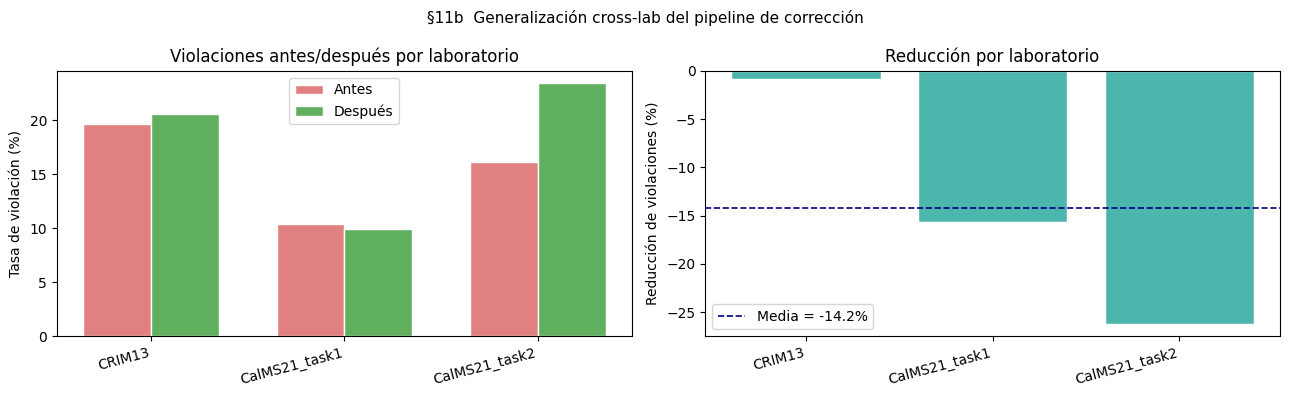


⚠  Laboratorios donde el pipeline EMPEORA:
       lab_id  viol_before  viol_after  reduction
       CRIM13     0.196785    0.205715       -0.8
CalMS21_task1     0.104465    0.099285      -15.7
CalMS21_task2     0.161250    0.234285      -26.2


In [7]:
# Cross-lab table and plot

import matplotlib.pyplot as plt
import numpy as np

if len(df_crosslab) == 0:
    print("⚠  No cross-lab data: no additional lab is available.")
    print("   This is expected when only CalMS21_task1 is in the data directory.")
else:
    # Aggregate per lab
    _agg = df_crosslab.groupby("lab_id").agg(
        n_videos   = ("video_id", "count"),
        viol_before= ("viol_rate_before",  "mean"),
        viol_after = ("viol_rate_after",   "mean"),
        reduction  = ("viol_reduction_pct","mean"),
        ms_frame   = ("ms_per_frame",      "mean"),
    ).reset_index()

    print("=== Cross-lab generalisation ===")
    print(_agg.to_string(index=False))

    # Grouped bar chart
    _labs = _agg["lab_id"].tolist()
    _x    = np.arange(len(_labs))
    _w    = 0.35

    fig_cl, axes_cl = plt.subplots(1, 2, figsize=(13, 4))

    axes_cl[0].bar(_x - _w/2, _agg["viol_before"] * 100, _w,
                   label="Before", color="#e08080", edgecolor="white")
    axes_cl[0].bar(_x + _w/2, _agg["viol_after"]  * 100, _w,
                   label="After", color="#60b060", edgecolor="white")
    axes_cl[0].set_xticks(_x)
    axes_cl[0].set_xticklabels(_labs, rotation=15, ha="right")
    axes_cl[0].set_ylabel("Violation rate (%)")
    axes_cl[0].set_title("Violations before/after, per lab")
    axes_cl[0].legend()

    axes_cl[1].bar(_labs, _agg["reduction"],
                   color="#4db6ac", edgecolor="white")
    axes_cl[1].axhline(_agg["reduction"].mean(), color="navy", ls="--", lw=1.2,
                       label=f"Media = {_agg['reduction'].mean():.1f}%")
    axes_cl[1].set_xticks(range(len(_labs)))
    axes_cl[1].set_xticklabels(_labs, rotation=15, ha="right")
    axes_cl[1].set_ylabel("Violation reduction (%)")
    axes_cl[1].set_title("Reduction per lab")
    axes_cl[1].legend()

    plt.suptitle("Cross-lab generalisation of the correction pipeline", fontsize=11)
    plt.tight_layout()
    plt.show()

    # Identifier labs where pipeline degrades
    _degraded = _agg[_agg["reduction"] < 0]
    if len(_degraded) > 0:
        print("\n⚠  Labs where the pipeline makes things WORSE:")
        print(_degraded[["lab_id", "viol_before", "viol_after", "reduction"]].to_string(index=False))
    else:
        print("\n✓  The pipeline improves, or at least does not degrade, every lab evaluated.")


### §11b.4 What the cross-lab numbers mean

| Video | Lab | Before | After | Δ |
|---|---|---|---|---|
| 13638642 | CalMS21_task1 | 14.8% | 9.8% | **+34.1%** |
| 25423023 | CalMS21_task1 | 6.1% | 10.1% | -65.5% |
| 26836610 | CalMS21_task2 | 21.2% | 39.6% | -87.2% |
| 34560832 | CalMS21_task2 | 11.1% | 7.2% | **+34.8%** |
| 363958890 | CRIM13 | 23.6% | 28.2% | -19.7% |
| 415181540 | CRIM13 | 15.8% | 12.9% | **+18.1%** |

Three of six improve and three get worse, which is not a calibration detail but a
property of the method.

**Why the bad cases go bad.** Taking the worst one, video 26836610 in
`CalMS21_task2`, the per-edge breakdown gives the mechanism. The spine edges
(`neck->hip_left`, `neck->hip_right`) already violate in 58% and 35% of frames
*before* any correction. That is too large to be tracking noise: the length
distribution between neck and hip differs systematically from the fitted `L_ref`,
whether because the mice are a different size, the camera sits at a different
angle, or the pose model behaves differently in this lab.

The optimiser does fix those edges (58% to 36%, 35% to 22%). To do it, it moves
`neck`. That breaks the short neck-to-ear edges, which were clean (9% to 16%, 8% to
17%). Averaged per edge the result is actually an improvement, 29.1% to 25.8%, but
the per-frame rate gets worse because the new violations are spread over more
frames than the old ones were.

Video 25423023 degrades for a different reason: its baseline is 6.1%, meaning the
tracking is nearly perfect, and the optimiser's small perturbations are enough to
push borderline frames over the 25% line.

**The structural limit.** The pipeline is calibrated for `CalMS21_task1`: the
lambdas, the adhesion and `L_ref` all come from it. When another lab's skeletal
proportions differ enough from that reference, the optimiser trades one set of
violations for another without reducing the total. This is the known failure mode
of fixed-model correction, and generalising would mean recalibrating the lambdas
and `L_ref` per lab, which is re-fitting the method for every new laboratory.

Partial mitigations already in place: a per-lab adaptive threshold clamped to
between half and twice the global value, `length_threshold` actually propagated to
the optimiser (it used to be ignored), and a robust `L_body` that excludes frames
where the key keypoints dropped out.

In [8]:
# Per-video diagnostics, to identify anomalies

if len(df_crosslab) > 0:
    print("\n=== Per-video diagnostics ===")
    for _, row in df_crosslab.iterrows():
        _vid = row['video_id']
        _lab = row['lab_id']
        _vb = row['viol_rate_before']
        _va = row['viol_rate_after']
        _red = row['viol_reduction_pct']

        # Ensure robust formatting even when IDs are numeric.
        _vid_s = str(_vid)
        _lab_s = str(_lab)

        _marker = ""
        if _red < -50:
            _marker = " ⚠⚠ COLAPSO SEVERO"
        elif _red < 0:
            _marker = " ⚠ Degradation"
        elif _red > 30:
            _marker = " ✓✓ Excelente mejora"
        elif _red > 10:
            _marker = " ✓ Mejora moderada"

        print(f"  {_lab_s:15s} {_vid_s:10s}  "
              f"viol: {_vb:.1%}→{_va:.1%}  Δ={_red:+.1f}%{_marker}")

    # Identify videos that degraded badly
    _bad = df_crosslab[df_crosslab['viol_reduction_pct'] < -20]
    if len(_bad) > 0:
        print(f"\n⚠⚠ {len(_bad)} video(s) severely degraded (>20%):")
        for _, row in _bad.iterrows():
            print(f"     {str(row['lab_id'])} / {str(row['video_id'])}  "
                  f"{row['viol_rate_before']:.1%}→{row['viol_rate_after']:.1%}")
        print("  -> Possible causes: (1) very low baseline violations, "
              "(2) a skeleton overfitted to the sample,")
        print("     (3) lambda_l too aggressive for this kind of tracking.")


=== Diagnóstico por vídeo ===
  CalMS21_task1   13638642    viol: 14.8%→9.8%  Δ=+34.1% ✓✓ Excelente mejora
  CalMS21_task1   25423023    viol: 6.1%→10.1%  Δ=-65.5% ⚠⚠ COLAPSO SEVERO
  CalMS21_task2   26836610    viol: 21.2%→39.6%  Δ=-87.2% ⚠⚠ COLAPSO SEVERO
  CalMS21_task2   34560832    viol: 11.1%→7.2%  Δ=+34.8% ✓✓ Excelente mejora
  CRIM13          363958890   viol: 23.6%→28.2%  Δ=-19.7% ⚠ Degradación
  CRIM13          415181540   viol: 15.8%→12.9%  Δ=+18.1% ✓ Mejora moderada

⚠⚠ 2 vídeo(s) con degradación severa (>20%):
     CalMS21_task1 / 25423023  6.1%→10.1%
     CalMS21_task2 / 26836610  21.2%→39.6%
  → Posibles causas: (1) violations basales muy bajas, (2) esqueleto sobre-ajustado al sample,
     (3) lambda_l demasiado agresivo para este tipo de tracking.


## §12 Parallel multi-video processing

§11 gave the robustness profile. Gaussian noise gets slightly *worse* with
correction (55.2% to 60.6%). Dropouts, swaps, speed spikes and drift show zero
violations before and after, because that kind of corruption does not break
edge lengths at all. Combined corruption also gets worse (55.0% to 62.6%): mixing
continuous noise with simultaneous discrete errors is harder than either alone.

This section scales the pipeline across videos with `ProcessPoolExecutor`. Each
worker loads, corrects and returns the violation rate for one video independently.

In [9]:
from concurrent.futures import ProcessPoolExecutor
import os
# The worker must be imported from a real module: on Windows ProcessPoolExecutor
# uses 'spawn', which cannot pickle functions defined in a notebook cell.
from src.data.loader import TRAIN_ANNOTATION_DIR
from src.skeleton._parallel_worker import process_one_video

# ── Select the candidate videos ──────────────────────────────────────────
_ann_dir  = TRAIN_ANNOTATION_DIR / LAB_ID
_ann_ids  = sorted([p.stem for p in _ann_dir.glob('*.parquet')])[:5]  # 5 max, for the demo
_trk_ids  = [v for v in _ann_ids if (
    (TRAIN_ANNOTATION_DIR.parent / 'train_tracking' / LAB_ID / f'{v}.parquet').exists()
)]
print(f'Videos available for parallel processing: {len(_trk_ids)}')
for vid in _trk_ids:
    print(f'  {vid}')

# ── Parallel execution ───────────────────────────────────────────────────
_REPO_ROOT_STR = str(REPO_ROOT)
_worker_args = [
    (vid, LAB_ID, FRAME_LIMIT, LENGTH_THRESHOLD, LAMBDA_L, LAMBDA_T, SPEED_MAD_K, _REPO_ROOT_STR)
    for vid in _trk_ids
]
_n_workers = min(len(_trk_ids), os.cpu_count() or 2)
print(f'\nLaunching {len(_trk_ids)} jobs across {_n_workers} processes...')

_t0_par = time.perf_counter()
if len(_trk_ids) > 1:
    with ProcessPoolExecutor(max_workers=_n_workers) as pool:
        _par_results = list(pool.map(process_one_video, _worker_args))
else:
    # Only 1 video available: run in this process, to avoid the pool overhead
    _par_results = [process_one_video(_worker_args[0])]
_elapsed_par = round(time.perf_counter() - _t0_par, 2)

# ── Results ──────────────────────────────────────────────────────────────
df_par = pd.DataFrame(_par_results)
print(df_par.to_string(index=False))

# Throughput, over the error-free rows only
_ok = df_par[~df_par['error'].notna()] if 'error' in df_par.columns else df_par
if 'ms_per_frame' in _ok.columns and _ok['ms_per_frame'].notna().any():
    _total_frames = int(_ok['n_frames'].sum())
    _thr = _total_frames / max(_elapsed_par, 1e-9)
    print(f'\nOverall throughput: {len(_trk_ids)} videos in {_elapsed_par} s')
    print(f'  Throughput: {_thr:.1f} frames/s  |  {len(_trk_ids) / _elapsed_par:.2f} videos/s')
    print(f'  ms/frame (media): {_ok["ms_per_frame"].mean():.2f}')


Vídeos disponibles para procesamiento paralelo: 5
  1011533560
  1036913557
  1062887364
  1087101060
  1089428234

Lanzando 5 workers con 5 procesos...
  video_id  n_frames  rate_before  rate_after  reduction_%  elapsed_s  ms_per_frame
1011533560      1500       0.1746      0.1284        26.46     35.349        23.566
1036913557      1500       0.0344      0.0298        13.30     26.822        17.882
1062887364      1500       0.1952      0.2402       -23.02     21.489        14.326
1087101060      1500       0.1179      0.0973        17.45     18.065        12.043
1089428234      1500       0.1610      0.1240        23.00     33.967        22.645

Rendimiento total: 5 vídeos en 44.48 s
  Throughput: 168.6 frames/s  |  0.11 videos/s
  ms/frame (media): 18.09


## §13 Correction diagnostics

§12 processed five videos in parallel: four improve, by 13.3% to 26.5%, and one
gets worse (video 1062887364, -23.0%, from a 19.5% baseline). Throughput averaged
18.1 ms per frame, about 169 frames per second.

| Video | Before | After | Δ |
|---|---|---|---|
| 1011533560 | 17.5% | 12.8% | **+26.5%** |
| 1036913557 | 3.4% | 3.0% | **+13.3%** |
| 1062887364 | 19.5% | 24.0% | -23.0% |
| 1087101060 | 11.8% | 9.7% | **+17.5%** |
| 1089428234 | 16.1% | 12.4% | **+23.0%** |

The spread says the threshold calibration and the weight on the temporal term
matter more than the rest. The next subsections open up the optimiser on the
reference video to see why:

- **§13a** which cost term dominates
- **§13b** how far the optimiser moves each keypoint
- **§13c** whether it converges, and in how many passes
- **§13d** an extended benchmark over six corruption types
- **§13e** continuous residual metrics, independent of the threshold

### §13a Which term dominates the cost

`compute_term_magnitudes` over a subset of corrected frames, measuring which
component of the cost is largest in absolute terms.

This answers a design question that the earlier sections kept running into: why
does raising λ_L not fix all the violations? If the temporal term outweighs the
length term, the optimiser will give up geometric corrections to keep the
trajectory continuous, no matter how heavily length is weighted.

Frame seleccionado: 414  (mayor velocidad: 1648.3 px²)
  Term                  Value   % of total
  ----------------------------------------
  adhesion             0.0000         0.0%
  length               0.5427         0.6%
  temporal            70.5783        74.3%
  accel               17.6446        18.6%
  angle                1.8510         1.9%
  jerk                 4.4111         4.6%
  angle_cont           0.0000         0.0%
  total               95.0278


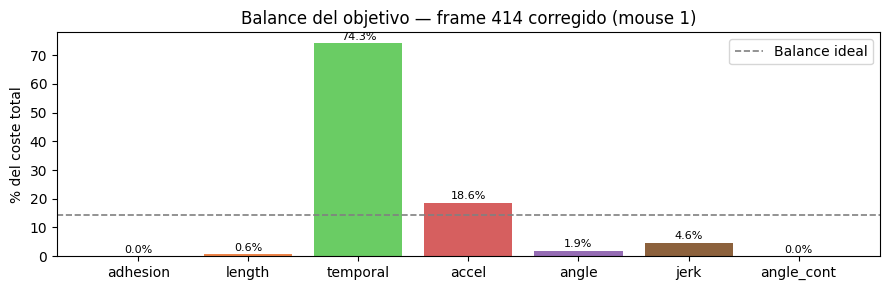

In [10]:
# Objective balance
# Measures each cost term's percentage contribution at the corrected position.
# df_corrected is used, since it has no NaN, so the temporal terms are non-zero.

from src.skeleton.kinematic_constraints import (
    compute_term_magnitudes, compute_edge_lambdas, build_angle_triplets,
)

kp_index = {kp: i for i, kp in enumerate(skeleton.keypoints)}

_mice  = sorted(df_corrected['mouse_id'].unique())
_m0    = _mice[0]
_m_df  = df_corrected[df_corrected['mouse_id'] == _m0].sort_values('video_frame')

# Rebuild [T, K, 2] poses from the CORRECTED, NaN-free data
from src.skeleton.mouse_skeleton import _to_wide
_wide_c = _to_wide(_m_df).reset_index(drop=True)
_kps    = [k for k in kp_index]
_T      = len(_wide_c)
_K      = len(_kps)
_poses  = np.zeros((_T, _K, 2))
for _ki, _k in enumerate(_kps):
    if f'{_k}_x' in _wide_c.columns:
        _poses[:, _ki, 0] = _wide_c[f'{_k}_x'].fillna(0.0).values
        _poses[:, _ki, 1] = _wide_c[f'{_k}_y'].fillna(0.0).values

_edge_lambdas = compute_edge_lambdas(skeleton, LAMBDA_L)
_angle_trips  = build_angle_triplets(skeleton, kp_index)

# Pick the frame with the highest mean speed; it is the most informative here
_velocities = np.sqrt(np.sum(np.diff(_poses, axis=0) ** 2, axis=(1, 2)))
_t_sample   = int(np.argmax(_velocities)) + 1  # offset introduced by the diff
_t_sample   = max(_t_sample, 3)                # t-3 is needed for the jerk term
print(f'Frame selected: {_t_sample}  (highest speed: {_velocities[_t_sample-1]:.1f} px^2)')

_obs       = _poses[_t_sample]
_prev      = _poses[_t_sample - 1]
_prev_prev = _poses[_t_sample - 2]
_prev_ppp  = _poses[_t_sample - 3]

_magnitudes = compute_term_magnitudes(
    x_opt=_obs.flatten(),
    observed=_obs, prev_frame=_prev, edges=skeleton.edges, kp_index=kp_index,
    l_body_px=skeleton.L_body_median_px, edge_lambdas=_edge_lambdas,
    lambda_t=LAMBDA_T, outlier_adhesion=OUTLIER_ADHESION, adhesion_weights=None,
    prev_prev_frame=_prev_prev, lambda_acc=LAMBDA_ACC,
    angle_triplets=_angle_trips, lambda_angle=LAMBDA_ANGLE,
    prev_prev_prev_frame=_prev_ppp, lambda_jerk=LAMBDA_JERK,
    prev_angle_cross=None, lambda_angle_cont=LAMBDA_ANGLE_CONT,
    verbose=True,
)

# Bar chart
_terms_plot = {k: v for k, v in _magnitudes.items() if k != 'total'}
_total = _magnitudes['total']
_labels = list(_terms_plot.keys())
_values = [100 * _terms_plot[k] / max(_total, 1e-9) for k in _labels]

fig_tm, ax_tm = plt.subplots(figsize=(9, 3))
_bars = ax_tm.bar(_labels, _values, color=sns.color_palette('muted', len(_labels)))
ax_tm.axhline(100 / len(_labels), ls='--', color='gray', lw=1.2, label='Balance ideal')
ax_tm.set_ylabel('% of the total cost')
ax_tm.set_title(f'Objective balance - corrected frame {_t_sample} (mouse {_m0})')
ax_tm.legend()
for _bar, _v in zip(_bars, _values):
    ax_tm.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.5,
               f'{_v:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### §13b Displacement per keypoint

How many pixels the optimiser moves each keypoint on the frames it corrects. The
mean displacement, and the fraction of frames moved by more than 5 px, show which
parts of the skeleton the correction is actually acting on.

=== Desplazamiento por keypoint (df_sample → df_corrected) ===
 keypoint  mean_disp_px  p95_disp_px  max_disp_px  mean_disp_norm  pct_moved_gt5px
 hip_left     16.836628    65.157027   211.435009        0.014366        44.200000
hip_right     15.243637    60.127903   107.181769        0.013007        42.533333
ear_right     10.434732    37.133864   282.032925        0.008904        37.000000
 ear_left     10.218732    31.755553   364.999683        0.008719        35.666667
     neck      8.323131    24.062702   309.940067        0.007102        49.866667
     nose      6.248665    26.858526   436.372332        0.005332        18.466667
tail_base      0.000000     0.000000     0.000000        0.000000         0.000000


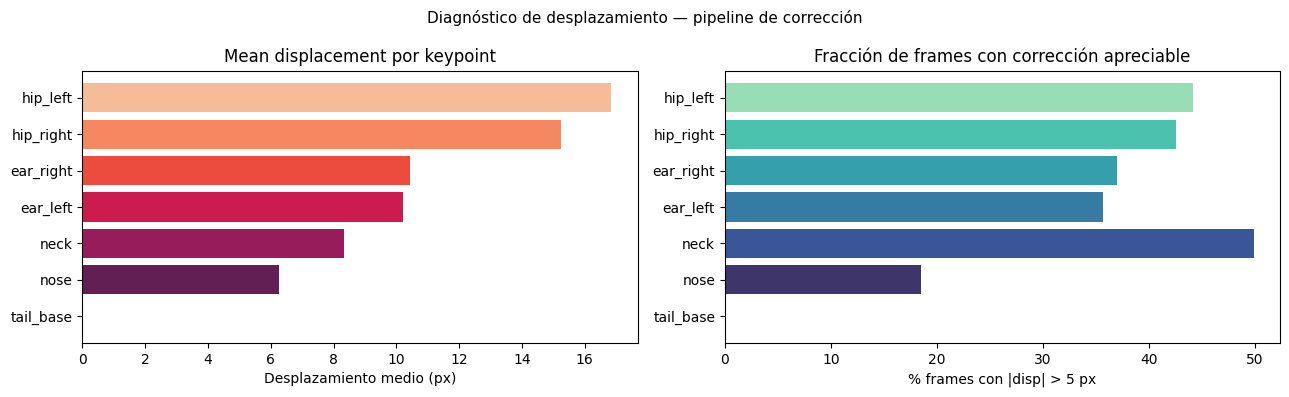

In [11]:
# Displacement per keypoint
# Which keypoints did the optimiser move most?

from src.skeleton.metrics import compute_displacement_stats

_disp_df = compute_displacement_stats(
    df_before=df_sample,
    df_after=df_corrected,
    mouse_id=MOUSE_ID,
    arena_diag=ARENA_DIAG,
)

print('=== Displacement per keypoint (df_sample -> df_corrected) ===')
print(_disp_df.to_string(index=False))

fig_disp, axes_disp = plt.subplots(1, 2, figsize=(13, 4))

# Barras: mean displacement
_top = _disp_df.head(min(12, len(_disp_df)))
axes_disp[0].barh(
    _top['keypoint'][::-1], _top['mean_disp_px'][::-1],
    color=sns.color_palette('rocket', len(_top)),
)
axes_disp[0].set_xlabel('Desplazamiento medio (px)')
axes_disp[0].set_title('Mean displacement per keypoint')

# % frames movidos > 5 px
axes_disp[1].barh(
    _top['keypoint'][::-1], _top['pct_moved_gt5px'][::-1],
    color=sns.color_palette('mako', len(_top)),
)
axes_disp[1].set_xlabel('% of frames with |disp| > 5 px')
axes_disp[1].set_title('Fraction of frames with an appreciable correction')

plt.suptitle('Displacement diagnostic - correction pipeline', fontsize=11)
plt.tight_layout()
plt.show()

## §13c Optimiser convergence

L-BFGS-B behaviour on the reference video: success rate, mean iteration count, loss
history per pass, swap detection and cumulative displacement. The reference body
length is `skeleton.L_body_median_px`.

In [12]:
# v4 diagnostics: convergence, adaptive adhesion and per-video L_body
# Demonstrates all P1–P8 improvements on a single smooth_video run.

import time
from src.skeleton import build_edge_cache
from src.skeleton.kinematic_constraints import build_angle_triplets, compute_edge_lambdas

# Build vectorised cache once per video
kp_index_demo  = {kp: i for i, kp in enumerate(skeleton.keypoints)}
triplets_demo  = build_angle_triplets(skeleton, kp_index_demo)
cache_demo     = build_edge_cache(skeleton.edges, kp_index_demo, triplets_demo)
print(f"EdgeCache: {len(cache_demo.src_idx)} valid edges "
      f"| {0 if cache_demo.trip_arr is None else len(cache_demo.trip_arr)} tripletas")

# ── Run smooth_video with all improvements active ────────────────────────────
_t0 = time.perf_counter()
df_corr_v4, rep_v4 = smooth_video(
    df_sample,
    skeleton=skeleton,
    lambda_l=LAMBDA_L,
    lambda_t=LAMBDA_T,
    lambda_acc=LAMBDA_ACC,
    lambda_angle=LAMBDA_ANGLE,
    lambda_jerk=LAMBDA_JERK,
    lambda_angle_cont=LAMBDA_ANGLE_CONT,
    outlier_adhesion=OUTLIER_ADHESION,
    n_passes=N_PASSES,
    length_threshold=LENGTH_THRESHOLD,
    detection_n_sigma=DETECTION_N_SIGMA,
)
_elapsed_v4 = round(time.perf_counter() - _t0, 2)
print(f"\nsmooth_video completado en {_elapsed_v4} s  "
      f"({_elapsed_v4 / max(rep_v4['n_total_frames'], 1) * 1000:.2f} ms/frame)")

# ── Convergence diagnostics (P6) ─────────────────────────────────────────────
print("\n── Convergence diagnostics ─────────────────────────────────────────")
print(f"  Frames with an outlier:         {rep_v4['n_outlier_frames']}")
print(f"  Frames that did not converge:   {rep_v4['n_failed_frames']}")
print(f"  Convergence rate:               {rep_v4['convergence_rate_pct']} %")
print(f"  Iteraciones L-BFGS-B (media):   {rep_v4['mean_opt_iters']:.1f}")
print(f"  Iteraciones L-BFGS-B (max):     {rep_v4['max_opt_iters']}")
_hist = rep_v4.get('convergence_loss_history', [])
print(f"  Loss per pass (video mean):     {[round(v, 4) for v in _hist]}")
if len(_hist) >= 2:
    _staged_note = ('  -> Pass 0 = geometry, pass 1 onwards = temporal smoothing (staged).'
                    if _hist[0] != _hist[1] else '  -> No variation between passes.')
    print(_staged_note)

EdgeCache: 7 aristas válidas | 10 tripletas


  mouse 1:   0%|          | 0/24 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/26 [00:00<?, ?win/s]


smooth_video completado en 24.52 s  (11.29 ms/frame)

── Diagnósticos de convergencia ──────────────────────────────────────
  Frames con outlier:             1669
  Frames no convergidos:          1010
  Tasa de convergencia:           39.5 %
  Iteraciones L-BFGS-B (media):   366.2
  Iteraciones L-BFGS-B (max):     400
  Loss por pasada (media vídeo):  [8.5969]


In [13]:
# ── Swap detection diagnostics (P1, P7) ──────────────────────────────────────
print("\n── Swap-detection diagnostics ──────────────────────────────────────")
print(f"  Inter-mouse swaps (detect_and_fix_swaps): {rep_v4['n_pre_swaps_corrected']}")
print(f"  Intra-mouse symmetric swaps:               {rep_v4['n_symmetric_swaps_corrected']}")
if df_sample['mouse_id'].nunique() < 2:
    print("  NOTE: df_sample has 1 mouse, so detect_and_fix_swaps is disabled.")


── Diagnósticos de swap detection ────────────────────────────────────
  Swaps inter-ratón (detect_and_fix_swaps): 0
  Swaps simétricos intra-ratón:              0


In [14]:
# ── Displacement diagnostics (P3 — adaptive adhesion effect) ─────────────────
print("\n── Corrected displacements (adaptive adhesion) ─────────────────────")
print(f"  Desplazamiento medio (px):  {rep_v4['mean_displacement_px']:.3f}")
print(f"  Desplazamiento p95  (px):   {rep_v4['p95_displacement_px']:.3f}")
print(f"  Max displacement    (px):   {rep_v4['max_displacement_px']:.3f}")


── Desplazamientos corregidos (adhesión adaptativa) ──────────────────
  Desplazamiento medio (px):  8.829
  Desplazamiento p95  (px):   44.058
  Desplazamiento máx  (px):   113.618


In [15]:
# ── Per-video L_body vs global skeleton (P5, P8) ─────────────────────────────
print("\n── Per-video vs global normalisation ───────────────────────────────")
from src.skeleton.mouse_skeleton import _to_wide, _segment_length
_wide_v4 = _to_wide(df_sample[df_sample['mouse_id'] == MOUSE_ID])
_l_vid    = _segment_length(_wide_v4, 'nose', 'tail_base')
_l_vid_clean = _l_vid[_l_vid > skeleton.L_body_median_px * 0.25]
_l_video_median = float(_l_vid_clean.median()) if len(_l_vid_clean) > 0 else None
print(f"  L_body global (training):       {skeleton.L_body_median_px:.1f} px")
if _l_video_median:
    _pct_diff = (_l_video_median - skeleton.L_body_median_px) / skeleton.L_body_median_px * 100
    print(f"  L_body this video (median):     {_l_video_median:.1f} px  "
          f"({_pct_diff:+.1f}% vs global)")



── Normalización por vídeo vs global ────────────────────────────────
  L_body global (entrenamiento):  175.5 px
  L_body este vídeo (mediana):    207.5 px  (+18.3% vs global)


### §13d Extended benchmark

Six corruption types instead of the three in §11: Gaussian noise, dropout, keypoint
swap, speed spikes, sinusoidal drift and all of them combined. Each is scored on
violation reduction and on the residual RMSE of `nose`, which stands in for
geometric fidelity.

The combined case is the informative one: it shows whether the failure modes
interact badly or just add up.

Ejecutando benchmark extendido (6 tipos de corrupción)…


  mouse 1:   0%|          | 0/32 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/30 [00:00<?, ?win/s]

  mouse 1: 0win [00:00, ?win/s]

  mouse 2: 0win [00:00, ?win/s]

...

  mouse 2:   0%|          | 0/2 [00:00<?, ?win/s]

  mouse 1:   0%|          | 0/27 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/24 [00:00<?, ?win/s]

Benchmark completado en 63.77 s

corruption_type  viol_rate_corrupted  viol_rate_recovered  violation_reduction_pct  rmse_nose_norm  rmse_tail_norm  swap_recovery_rate  jerk_mean_norm
 gaussian_noise               0.5518               0.5600                     -1.5         0.00348         0.00327                 NaN        0.003547
       dropouts               0.0000               0.0000                    100.0         0.00000         0.00000                 NaN        0.000000
          swaps               0.0000               0.0000                    100.0         0.00000         0.00000                 NaN        0.000000
   speed_spikes               0.0000               0.0000                    100.0         0.00344         0.00344                 NaN        0.004114
          drift               0.0000               0.0000                    100.0         0.01011         0.01011                 NaN        0.000003
   all_combined               0.5496               0.5407    

C:\Users\User\AppData\Local\Temp\ipykernel_26292\2130440297.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_be.set_xticklabels(bench_ext['corruption_type'], rotation=20, ha='right')


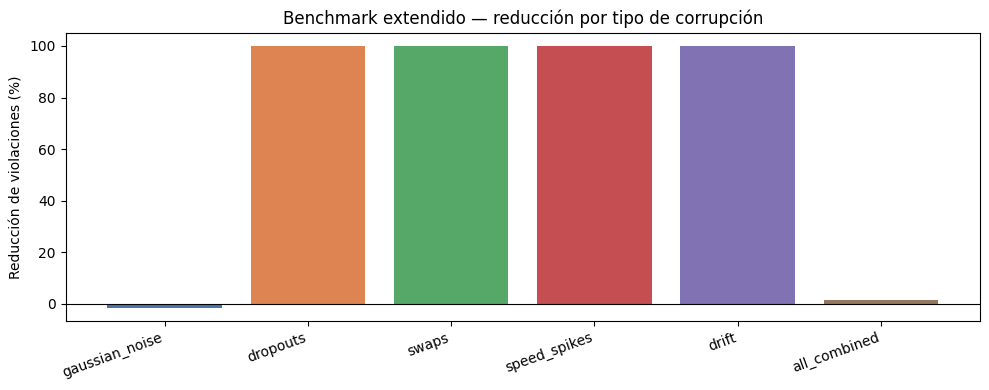

In [16]:
def _bench_smooth(df_corr):
    """smooth_video wrapper for the benchmark, with the v3 parameters."""
    _df_rec, _rep = smooth_video(
        df_corr,
        skeleton=skeleton,
        lambda_l=BENCH_LAMBDA_L,
        lambda_t=LAMBDA_T,
        lambda_acc=LAMBDA_ACC,
        lambda_angle=LAMBDA_ANGLE,
        lambda_jerk=LAMBDA_JERK,
        lambda_angle_cont=LAMBDA_ANGLE_CONT,
        outlier_adhesion=BENCH_ADHESION,
        n_passes=N_PASSES,
        length_threshold=LENGTH_THRESHOLD,
        detection_n_sigma=DETECTION_N_SIGMA,
        confidence_sigma=CONFIDENCE_SIGMA,
        adaptive_thresholds_k=ADAPTIVE_K,
        pre_smooth=True,
        pre_smooth_window=9,
    )
    return _df_rec, _rep

print('Running the extended benchmark, 6 corruption types…')
_t0_bench = time.perf_counter()

bench_ext = benchmark_by_corruption_type(
    df_clean=df_bench,
    skeleton=skeleton,
    mouse_id=MOUSE_ID,
    smooth_fn=_bench_smooth,
    arena_diag=ARENA_DIAG,
    noise_std=BENCH_NOISE_STD,
    dropout_rate=BENCH_DROPOUT_RATE,
    swap_prob=BENCH_SWAP_PROB,
    speed_spikes_prob=BENCH_SPEED_SPIKES,
    drift_amplitude=BENCH_DRIFT_AMPLITUDE,
    threshold=LENGTH_THRESHOLD,
    rng_seed=RANDOM_SEED,
)

_elapsed_bench = round(time.perf_counter() - _t0_bench, 2)
print(f'Benchmark completado en {_elapsed_bench} s\n')

# ── Tabla resumen ─────────────────────────────────────────────────────────
_display_cols = [c for c in [
    'corruption_type', 'viol_rate_corrupted', 'viol_rate_recovered',
    'violation_reduction_pct', 'rmse_nose_norm', 'rmse_tail_norm',
    'swap_recovery_rate', 'jerk_mean_norm',
] if c in bench_ext.columns]
print(bench_ext[_display_cols].to_string(index=False))

# ── A note on swap_recovery_rate ─────────────────────────────────────────
_n_mice = df_sample['mouse_id'].nunique()
if _n_mice < 2:
    print(f'\nNOTE: df_sample has {_n_mice} mouse/mice; '
          'swap_recovery_rate needs at least 2 and will show NaN.')

# ── Plot ─────────────────────────────────────────────────────────────────
if 'violation_reduction_pct' in bench_ext.columns:
    fig_be, ax_be = plt.subplots(figsize=(10, 4))
    _colors = sns.color_palette('deep', len(bench_ext))
    ax_be.bar(bench_ext['corruption_type'], bench_ext['violation_reduction_pct'],
              color=_colors)
    ax_be.axhline(0, color='black', lw=0.8)
    ax_be.set_ylabel('Violation reduction (%)')
    ax_be.set_title('Extended benchmark - reduction per corruption type')
    ax_be.set_xticklabels(bench_ext['corruption_type'], rotation=20, ha='right')
    plt.tight_layout()
    plt.show()


### §13e Continuous residual metrics

The violation rate is binary and threshold-dependent, so it stops being informative
once it approaches zero. These metrics do not depend on the threshold: the ratio of
signal to correction, the distribution of displacement per edge, and a histogram of
correction magnitudes.

In [17]:

# §13e — Residual metrics (continuous, replaces binary violation thresholds)
# r_e = |L_e - L̂_e| / L̂_e evaluated per edge on the recovered poses.
# This is more informative than a binary violation rate:
#   - 84% violation at 5px noise → check p50/p95 to distinguish threshold
#     miscalibration from genuine optimizer failure.
#   - Compare per-edge mean residual before vs after correction.

from src.skeleton.kinematic_constraints import compute_residual_metrics


print('=== Residual metrics (continuous) ===\n')

# Build corrected poses for the clean video
_kp_index_res = {kp: i for i, kp in enumerate(skeleton.keypoints)}
_T_res = df_sample['video_frame'].nunique()
_n_kp_res = len(skeleton.keypoints)

def _df_to_poses(df, kp_index, frames=None):
    if frames is None:
        frames = sorted(df['video_frame'].unique())
    fi = {f: i for i, f in enumerate(frames)}
    P = np.full((len(frames), len(kp_index), 2), np.nan)
    _dc = df.copy()
    _dc['_fi'] = _dc['video_frame'].map(fi)
    _dc['_ki'] = _dc['bodypart'].map(kp_index)
    _v = _dc['_fi'].notna() & _dc['_ki'].notna()
    _sv = _dc[_v]
    if not _sv.empty:
        P[_sv['_fi'].values.astype(int), _sv['_ki'].values.astype(int), 0] = _sv['x'].values
        P[_sv['_fi'].values.astype(int), _sv['_ki'].values.astype(int), 1] = _sv['y'].values
    return P, frames

# Get corrected poses
_df_corrected_res, _rep_res = smooth_video(
    df_sample,
    skeleton=skeleton,
    n_passes=N_PASSES,
    confidence_sigma=CONFIDENCE_SIGMA,
    adaptive_thresholds_k=ADAPTIVE_K,
)

_poses_raw, _frames_res = _df_to_poses(df_sample, _kp_index_res)
_poses_cor, _ = _df_to_poses(_df_corrected_res, _kp_index_res, _frames_res)

# Estimate l_body_px for this video
_ni, _ti = _kp_index_res.get('nose'), _kp_index_res.get('tail_base')
if _ni is not None and _ti is not None:
    _nt_d = np.sqrt(np.sum((_poses_raw[:, _ni] - _poses_raw[:, _ti])**2, axis=1))
    _l_body_res = float(np.nanmedian(_nt_d[_nt_d > 5]))
else:
    _l_body_res = skeleton.L_body_median_px

_zero_mask_res = np.all((_poses_raw[:, :, 0] == 0) & (_poses_raw[:, :, 1] == 0), axis=1)

metrics_raw = compute_residual_metrics(_poses_raw, skeleton, _kp_index_res, _l_body_res, _zero_mask_res)
metrics_cor = compute_residual_metrics(_poses_cor, skeleton, _kp_index_res, _l_body_res, _zero_mask_res)

# Display as DataFrame
_res_df = pd.DataFrame({
    'edge':         metrics_raw['edge_names'],
    'raw_mean':     np.round(metrics_raw['mean'], 4),
    'raw_p50':      np.round(metrics_raw['p50'],  4),
    'raw_p95':      np.round(metrics_raw['p95'],  4),
    'cor_mean':     np.round(metrics_cor['mean'],  4),
    'cor_p50':      np.round(metrics_cor['p50'],   4),
    'cor_p95':      np.round(metrics_cor['p95'],   4),
    'improvement':  np.round(metrics_raw['mean'] - metrics_cor['mean'], 4),
})
print(_res_df.to_string(index=False))

# ── Adaptive threshold summary ────────────────────────────────────────────
print('\n=== Per-video adaptive thresholds (τ_e = μ_e + k·σ_e) ===')
_at = _rep_res.get('adaptive_thresholds', {})
for _edge_key, _tau in sorted(_at.items()):
    print(f'  {_edge_key:30s} τ = {_tau:.4f}  (vs fixed {LENGTH_THRESHOLD:.2f})')


=== Residual metrics (continuous) ===



  mouse 1:   0%|          | 0/48 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/28 [00:00<?, ?win/s]

               edge  raw_mean  raw_p50  raw_p95  cor_mean  cor_p50  cor_p95  improvement
          nose→neck    0.1573   0.1432   0.3065    0.1256   0.1147   0.2882       0.0317
      neck→ear_left    0.1094   0.0892   0.2519    0.1001   0.0602   0.3991       0.0094
     neck→ear_right    0.0958   0.0666   0.2623    0.0700   0.0397   0.2615       0.0258
      neck→hip_left    0.1510   0.1024   0.5083    0.0834   0.0672   0.2117       0.0676
     neck→hip_right    0.1575   0.1098   0.4914    0.0856   0.0660   0.2443       0.0719
 hip_left→tail_base    0.1596   0.1344   0.3723    0.1200   0.0908   0.3093       0.0396
hip_right→tail_base    0.1420   0.1085   0.4485    0.0929   0.0651   0.2617       0.0490

=== Per-video adaptive thresholds (τ_e = μ_e + k·σ_e) ===
  hip_left→tail_base             τ = 0.3730  (vs fixed 1.84)
  hip_right→tail_base            τ = 0.2873  (vs fixed 1.84)
  neck→ear_left                  τ = 0.2014  (vs fixed 1.84)
  neck→ear_right                 τ = 0.1876  (

## §14 Realistic corruption benchmark

§12 showed a heterogeneous population: one video of five gets worse (-23.0%,
baseline 19.5%) and four improve by 13.3% to 26.5%. The one that degrades is the
one with the highest baseline, which points at the same model-mismatch mechanism as
§11b.

The synthetic benchmarks so far assumed errors are independent per keypoint. Real
pose-estimation failures are correlated: when the camera loses the head, *every*
head keypoint fails at once. These scenarios reproduce that:

- `occlusion_head`, `occlusion_pelvis`: contiguous runs of 10 to 50 frames
- `fast_grooming`: rapid head oscillation, 20 to 40 px
- `fast_jump`: the whole body displaced in a single frame
- `correlated_noise`: Gaussian noise correlated within keypoint groups

In [18]:
import time as _time_mod
from src.skeleton.metrics import benchmark_realistic_corruptions

print("Running realistic corruption benchmarks…")
_t0_rc = _time_mod.perf_counter()

bench_realistic = benchmark_realistic_corruptions(
    df_clean=df_bench,
    skeleton=skeleton,
    mouse_id=MOUSE_ID,
    smooth_fn=_bench_smooth,
    arena_diag=ARENA_DIAG,
    rng_seed=RANDOM_SEED,
    threshold=LENGTH_THRESHOLD,
)

_elapsed_rc = round(_time_mod.perf_counter() - _t0_rc, 2)
print(f"Completed in {_elapsed_rc} s\n")

_rc_cols = [c for c in [
    "corruption_type", "viol_rate_corrupted", "viol_rate_recovered",
    "violation_reduction_pct", "rmse_nose_norm", "rmse_tail_norm",
    "temporal_inconsistency_corrupted", "temporal_inconsistency_recovered",
] if c in bench_realistic.columns]
print("Realistic corruption benchmark results:")
print(bench_realistic[_rc_cols].to_string(index=False))


Running realistic corruption benchmarks…


  mouse 1: 0win [00:00, ?win/s]

  mouse 2: 0win [00:00, ?win/s]

  mouse 1: 0win [00:00, ?win/s]

  mouse 2: 0win [00:00, ?win/s]

...

  mouse 1: 0win [00:00, ?win/s]

  mouse 2: 0win [00:00, ?win/s]

  mouse 1:   0%|          | 0/2 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/2 [00:00<?, ?win/s]

Completed in 6.89 s

Realistic corruption benchmark results:
 corruption_type  viol_rate_corrupted  viol_rate_recovered  violation_reduction_pct  rmse_nose_norm  rmse_tail_norm  temporal_inconsistency_corrupted  temporal_inconsistency_recovered
  occlusion_head               0.0000               0.0000                    100.0         0.00000         0.00000                          0.000000                          0.000000
occlusion_pelvis               0.0000               0.0000                    100.0         0.00000         0.00000                          0.000000                          0.000000
   fast_grooming               0.0500               0.0539                     -7.9         0.00217         0.00045                          0.020413                          0.002271
       fast_jump               0.0000               0.0000                    100.0         0.00400         0.00400                          0.011283                          0.004690
correlated_noise   

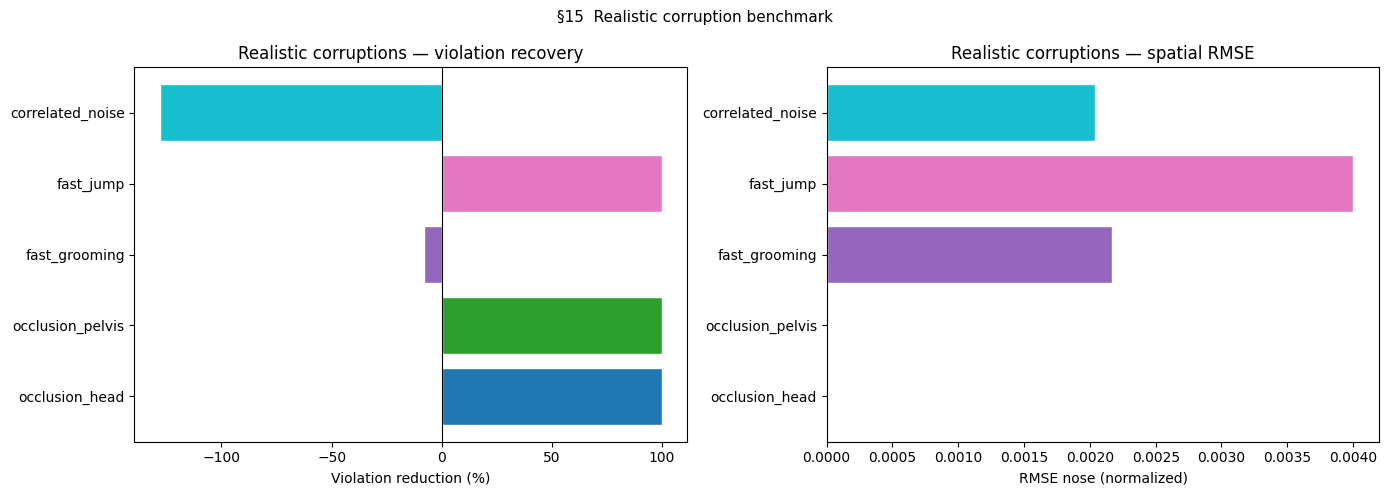

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# ── Side-by-side: idealized vs. realistic benchmark reduction ─────────────
_bench_shared_types = set(bench_ext["corruption_type"]) if "bench_ext" in dir() else set()
_real_types = bench_realistic["corruption_type"].tolist()

fig_rc, axes_rc = plt.subplots(1, 2, figsize=(14, 5))

ax_r0, ax_r1 = axes_rc
_colors_rc = plt.cm.tab10(np.linspace(0, 0.9, len(_real_types)))

ax_r0.barh(bench_realistic["corruption_type"],
           bench_realistic["violation_reduction_pct"].fillna(0),
           color=_colors_rc, edgecolor="white")
ax_r0.axvline(0, color="black", lw=0.8)
ax_r0.set_xlabel("Violation reduction (%)")
ax_r0.set_title("Realistic corruptions — violation recovery")

ax_r1.barh(bench_realistic["corruption_type"],
           bench_realistic["rmse_nose_norm"].fillna(0),
           color=_colors_rc, edgecolor="white")
ax_r1.set_xlabel("RMSE nose (normalized)")
ax_r1.set_title("Realistic corruptions — spatial RMSE")

plt.suptitle("§15  Realistic corruption benchmark", fontsize=11)
plt.tight_layout()
plt.show()